# 🏭 Smart Manufacturing — Industry 4.0 AI System
## Graph of Graphs Architecture using LangGraph + Groq

---

### 🏗️ Architecture: Graph of Graphs (Multi-Graph / Subgraph Pattern)

```
┌─────────────────────────────────────────────────────────┐
│                  PLANT MANAGER GRAPH                    │
│                  (Top-Level Orchestrator)               │
│                                                         │
│   ┌─────────────┐         ┌──────────────────────────┐  │
│   │Plant Manager│─────────▶  Situation Assessor      │  │
│   │   Agent     │         └──────────┬───────────────┘  │
│   └─────────────┘                    │                  │
│                           ┌──────────▼───────────────┐  │
│                           │  PRODUCTION  SUBGRAPH    │  │
│                           │  ┌──────────────────┐    │  │
│                           │  │ Robotics Planner │    │  │
│                           │  └────────┬─────────┘    │  │
│                           │       ┌───┴────┐          │  │
│                           │  Arm Control  Line Speed  │  │
│                           │    Agent      Agent       │  │
│                           └──────────────────────────┘  │
│                           ┌──────────────────────────┐  │
│                           │  MAINTENANCE SUBGRAPH    │  │
│                           │  ┌──────────────────┐    │  │
│                           │  │  Sensor Analyst  │    │  │
│                           │  └────────┬─────────┘    │  │
│                           │       ┌───┴────┐          │  │
│                           │  Failure Risk  Repair     │  │
│                           │   Scorer      Scheduler   │  │
│                           └──────────────────────────┘  │
│                                       │                  │
│                           ┌───────────▼──────────────┐  │
│                           │   Downtime Risk Report   │  │
│                           └──────────────────────────┘  │
└─────────────────────────────────────────────────────────┘
```

---

### 🆚 Graph of Graphs vs Single Graph (Marketing Campaign P7)

```
Marketing Campaign (P7 — Single Graph):   Smart Mfg (P8 — Graph of Graphs):

  One StateGraph                            ONE parent StateGraph
  One CampaignState                           + TWO child StateGraphs
  All agents share same state               Each subgraph has OWN state
  CEO knows about every worker              Plant Manager knows subgraphs,
  All 9 nodes visible in one graph            NOT individual workers
                                            Subgraphs are BLACK BOXES
                                              to the parent graph

  graph.add_node('keyword_worker', fn)      prod_graph = StateGraph(ProdState)
  graph.add_node('blog_worker', fn)         prod_app = prod_graph.compile()
  graph.add_node('caption_worker', fn)      # compiled subgraph becomes ONE node
  ...                                       parent.add_node('production', prod_app)
```

### 🔑 Key Concept: Compiled Subgraph as a Node

```python
# A compiled LangGraph app can be USED AS A NODE in another graph!
# This is the core mechanic of Graph of Graphs:

prod_app  = production_graph.compile()   # compile subgraph
maint_app = maintenance_graph.compile()  # compile subgraph

parent = StateGraph(PlantState)
parent.add_node('production',  prod_app)   # subgraph IS a node!
parent.add_node('maintenance', maint_app)  # subgraph IS a node!
```

### 🏭 Real-World Analogy

```
Plant Manager (parent graph):
  - Reads daily sensor reports
  - Delegates to Production Team OR Maintenance Team
  - Receives team summaries back
  - Does NOT micromanage individual robots or sensors

Production Team (subgraph — autonomous):
  - Has its own internal workflow
  - Robotics Planner breaks down the task
  - Arm Control + Line Speed agents execute
  - Returns ONE summary to Plant Manager

Maintenance Team (subgraph — autonomous):
  - Has its own internal workflow
  - Sensor Analyst reads all sensor data
  - Failure Risk Scorer + Repair Scheduler execute
  - Returns ONE summary to Plant Manager
```

---

### Step 0: Loading Environment & Liabraries

In [18]:
from dotenv import load_dotenv
load_dotenv()
import os

In [19]:
# pydantic: For structured data validation
from pydantic import BaseModel, Field

# LangChain components for prompts and parsing
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import PydanticOutputParser

# LangChain message types
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# LangChain runnable
from langchain_core.runnables import RunnablePassthrough

# LangGraph
from langgraph.graph import StateGraph, END

### Step 0: Loading/Initializing LLM

In [20]:
from langchain_groq import ChatGroq

# Groq automatically reads GROQ_API_KEY from environment variables

model = ChatGroq(
    model="llama-3.3-70b-versatile",   # or llama-3.3-70b-versatile
    temperature=0.7
)

llm = model

In [21]:
# ---- TEST ----
try:
    response = llm.invoke("Say hello in one sentence.")
    print("✅ Groq LLM initialized successfully")
    print("Response:", response.content)

except Exception as e:
    print("❌ Groq LLM initialization failed")
    print(e)

✅ Groq LLM initialized successfully
Response: Hello, it's nice to meet you and I'm here to help with any questions or topics you'd like to discuss.


## 🔑 Step 3 — API Keys + Rate Limit Helper

We include a retry decorator here because Graph of Graphs fires
many LLM calls in parallel — same lesson learned from Project 7.

In [22]:
import time
import operator
from functools import wraps

# os.environ["GROQ_API_KEY"] = "your_groq_api_key_here"

# Option B: .env file
# from dotenv import load_dotenv
# load_dotenv()


def with_retry(func):
    """
    Retry decorator for Groq rate limit errors (429).

    Graph of Graphs fires multiple LLM calls simultaneously
    (parallel subgraph nodes). Free-tier Groq has ~8000 TPM.
    This decorator catches 429s and waits before retrying.

    Lesson from Project 7: always include this for parallel graphs.
    """
    @wraps(func)
    def wrapper(*args, **kwargs):
        max_retries = 5
        for attempt in range(max_retries):
            try:
                return func(*args, **kwargs)
            except Exception as e:
                if "rate_limit_exceeded" in str(e) or "429" in str(e):
                    wait = 20 * (attempt + 1)   # 20s, 40s, 60s ...
                    print(f"   ⏳ Rate limit — waiting {wait}s (attempt {attempt+1}/{max_retries})...")
                    time.sleep(wait)
                else:
                    raise
        raise Exception("Max retries exceeded")
    return wrapper


print("✅ Environment ready!")
print(f"   Groq: {'*' * 20}{os.environ.get('GROQ_API_KEY', '')[-4:]}")
print()
print("   with_retry decorator loaded — protects against Groq 429 rate limits")

✅ Environment ready!
   Groq: ********************cbTi

   with_retry decorator loaded — protects against Groq 429 rate limits


## 📋 Step 4 — State Definitions (THREE separate states!)

### The Most Important Design Decision in Graph of Graphs

In a single-graph architecture (Projects 1-7), there is ONE shared state.
In Graph of Graphs, **each graph owns its own state**.

```
Single Graph (P7):                 Graph of Graphs (P8):

  CampaignState                      PlantState         ← parent
    product_brief                      plant_situation
    campaign_strategy                  production_report
    seo_brief                          maintenance_report
    blog_post                          final_risk_report
    social_captions                    messages
    ... (all 12 fields)                (only 5 fields!)

                                   ProductionState    ← subgraph 1
                                     production_task
                                     robotics_plan
                                     arm_control_actions
                                     line_speed_actions
                                     production_summary
                                     messages

                                   MaintenanceState   ← subgraph 2
                                     sensor_data
                                     sensor_analysis
                                     failure_risk_scores
                                     repair_schedule
                                     maintenance_summary
                                     messages
```

**Why separate states?**
- Each subgraph is AUTONOMOUS — it knows nothing about other subgraphs
- The parent only sees summaries — it never sees internal subgraph details
- This is true encapsulation — just like real org structures
- Subgraphs can be reused, tested, and modified independently

**How does data flow between states?**
The parent passes a task TO the subgraph (input field).
The subgraph writes a summary BACK to the parent (output field).
The bridge is the `invoke()` call inside a wrapper node.

In [23]:
from typing import TypedDict, Optional, Annotated


# ═══════════════════════════════════════════════════════════
# STATE 1: PlantState — owned by the TOP-LEVEL parent graph
# This is what the Plant Manager sees and works with.
# It does NOT contain any internal subgraph details.
# ═══════════════════════════════════════════════════════════
class PlantState(TypedDict):
    """
    The Plant Manager's view of the world.

    Notice how SMALL this state is compared to the full system.
    The Plant Manager works at a HIGH LEVEL:
    - Receives a daily plant situation report
    - Gets a production team summary back
    - Gets a maintenance team summary back
    - Writes the final downtime risk report

    The Plant Manager NEVER sees:
    - Individual robot arm positions
    - Individual sensor readings
    - Internal team workflows
    This is the encapsulation benefit of Graph of Graphs.
    """
    # Input: daily plant situation (sensor alerts, production targets)
    plant_situation: str

    # Tier 1: Plant Manager's strategic assessment + task assignments
    manager_assessment: Optional[str]

    # Tier 2: What each TEAM reports back (summaries only, not internals)
    production_report:  Optional[str]   # ← filled by Production Subgraph
    maintenance_report: Optional[str]   # ← filled by Maintenance Subgraph

    # Final output: consolidated downtime risk report
    final_risk_report: Optional[str]

    # Annotated for parallel subgraph execution safety (lesson from P7!)
    messages: Annotated[list, operator.add]


# ═══════════════════════════════════════════════════════════
# STATE 2: ProductionState — owned by the PRODUCTION subgraph
# The parent graph NEVER directly reads/writes these fields.
# ═══════════════════════════════════════════════════════════
class ProductionState(TypedDict):
    """
    The Production Team's internal state.

    This state is PRIVATE to the production subgraph.
    The parent (PlantState) only receives 'production_summary'
    — it never sees robotics_plan, arm_control_actions, etc.

    This is why Graph of Graphs scales to large systems:
    each team manages its own complexity internally.
    """
    # Input: task assigned by Plant Manager
    production_task: str

    # Internal: Robotics Planner breaks down the task
    robotics_plan: Optional[str]

    # Internal: Worker agents execute the plan
    arm_control_actions: Optional[str]    # ← Robot Arm Control Agent
    line_speed_actions:  Optional[str]    # ← Line Speed Agent

    # Output: what gets returned to PlantState (the ONLY bridge)
    production_summary: Optional[str]

    messages: Annotated[list, operator.add]


# ═══════════════════════════════════════════════════════════
# STATE 3: MaintenanceState — owned by the MAINTENANCE subgraph
# Same encapsulation principle as ProductionState.
# ═══════════════════════════════════════════════════════════
class MaintenanceState(TypedDict):
    """
    The Maintenance Team's internal state.

    Again private to the maintenance subgraph.
    Parent only receives 'maintenance_summary'.
    """
    # Input: sensor data + maintenance task from Plant Manager
    sensor_data: str

    # Internal: Sensor Analyst processes raw data
    sensor_analysis: Optional[str]

    # Internal: Specialist agents act on the analysis
    failure_risk_scores: Optional[str]   # ← Failure Risk Scorer Agent
    repair_schedule:     Optional[str]   # ← Repair Scheduler Agent

    # Output: what gets returned to PlantState (the ONLY bridge)
    maintenance_summary: Optional[str]

    messages: Annotated[list, operator.add]


print("✅ All 3 states defined!")
print()
print("   PlantState       (parent) :", list(PlantState.__annotations__.keys()))
print("   ProductionState  (sub 1)  :", list(ProductionState.__annotations__.keys()))
print("   MaintenanceState (sub 2)  :", list(MaintenanceState.__annotations__.keys()))
print()
print("   Key insight: PlantState has NO production/maintenance internals.")
print("   It only sees 'production_report' and 'maintenance_report' — the summaries.")

✅ All 3 states defined!

   PlantState       (parent) : ['plant_situation', 'manager_assessment', 'production_report', 'maintenance_report', 'final_risk_report', 'messages']
   ProductionState  (sub 1)  : ['production_task', 'robotics_plan', 'arm_control_actions', 'line_speed_actions', 'production_summary', 'messages']
   MaintenanceState (sub 2)  : ['sensor_data', 'sensor_analysis', 'failure_risk_scores', 'repair_schedule', 'maintenance_summary', 'messages']

   Key insight: PlantState has NO production/maintenance internals.
   It only sees 'production_report' and 'maintenance_report' — the summaries.


## 👑 Step 5 — Parent Graph: Plant Manager Agent

**Role:** Read the plant situation → make strategic decisions → assign tasks to teams.

The Plant Manager is the **only agent** in the parent graph's Tier 1.
It decides:
- What the Production Team should focus on
- What sensor data the Maintenance Team should investigate
- What the risk threshold is for stopping production

Crucially, it outputs TWO task strings:
- `production_task` → fed into ProductionState as input
- `sensor_data` → fed into MaintenanceState as input

This is the **cross-state data bridge** — how parent passes work to subgraphs.

In [24]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage


@with_retry
def plant_manager_agent(state: dict) -> dict:
    """
    Parent Graph — Plant Manager Agent.

    Reads the plant situation and produces:
    1. A strategic assessment of the overall plant health
    2. A specific production task for the Production Subgraph
    3. A sensor data summary for the Maintenance Subgraph

    The 'production_task' and 'sensor_data' outputs are what
    gets injected into the subgraph states when they're invoked.

    Reads:  state['plant_situation']   (user input)
    Writes: state['manager_assessment'] (stays in PlantState)
            state['production_task']    (→ passed to ProductionState)
            state['sensor_data']        (→ passed to MaintenanceState)

    Note: production_task and sensor_data are NOT in PlantState.
    They're extracted from manager_assessment inside the bridge nodes.
    """
    print("\n" + "="*60)
    print("👑 PLANT MANAGER [Parent Graph] — Assessing plant situation...")
    print("="*60)
    print(f"   Situation: {state['plant_situation'][:80]}...")

    # llm = ChatGroq(
    #     model="llama-3.1-8b-instant",
    #     temperature=0.3,    # Strategic decisions need clarity, not creativity
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a Plant Manager at a smart manufacturing facility.
You oversee two autonomous teams: Production Team (robotics) and Maintenance Team (sensors).
You do NOT micromanage — you assess the situation and delegate clearly.

Read the plant situation report and output:

PLANT MANAGER ASSESSMENT
========================

## Overall Plant Health Status
[CRITICAL / WARNING / NORMAL] — one sentence summary

## Strategic Priority
[What is the #1 thing that must be addressed in the next shift?]

## PRODUCTION TEAM TASK
[Specific instruction for the robotics/production team.
 Include: current production target, any speed/output adjustments needed,
 which assembly lines are affected, quality thresholds]

## MAINTENANCE TEAM TASK
[Specific instruction for the sensor/maintenance team.
 Include: which sensors to prioritize, failure risk threshold,
 which equipment needs inspection, acceptable downtime window]

## Escalation Trigger
[Under what condition should teams escalate back to you immediately?]"""),

        HumanMessage(content=f"Plant Situation Report:\n\n{state['plant_situation']}")
    ]

    response   = llm.invoke(messages)
    assessment = response.content

    print(f"   ✅ Assessment complete! ({len(assessment)} chars)")
    print("   → Delegating to Production Subgraph + Maintenance Subgraph")

    return {
        "manager_assessment": assessment,
        "messages": [{"role": "plant_manager",
                      "content": "[Parent] Plant situation assessed. Delegating to 2 subgraphs."}]
    }


print("✅ Plant Manager Agent defined!")
print("   Reads : plant_situation")
print("   Writes: manager_assessment (contains embedded tasks for both subgraphs)")

✅ Plant Manager Agent defined!
   Reads : plant_situation
   Writes: manager_assessment (contains embedded tasks for both subgraphs)


## 🤖 Step 6 — Production Subgraph: All 3 Agents

### Subgraph Internal Structure

```
ProductionState injected with 'production_task'
         ↓
   Robotics Planner          ← reads task → writes robotics_plan
       ↓         ↓
  Arm Control   Line Speed   ← both read robotics_plan (parallel)
   Agent         Agent
       ↓         ↓
   Production Summarizer     ← reads all outputs → writes production_summary
         ↓
  'production_summary' extracted → written to PlantState.production_report
```

Notice the Production Subgraph has its OWN mini-hierarchy:
Planner (strategy) → Workers (execution) → Summarizer (reporting up)

The **Summarizer** is unique to Graph of Graphs — every subgraph needs
one agent whose job is to **package the team's work into a summary**
that the parent graph can consume.

In [25]:
@with_retry
def robotics_planner(state: dict) -> dict:
    """
    Production Subgraph — Robotics Planner.

    The 'team lead' within the production subgraph.
    Reads the task from Plant Manager and creates an execution plan
    that the two worker agents (Arm Control + Line Speed) will follow.

    Reads:  state['production_task']  (injected from PlantState)
    Writes: state['robotics_plan']    (read by Arm Control + Line Speed)
    """
    print("\n" + "─"*60)
    print("🤖 ROBOTICS PLANNER [Production Subgraph] — Planning...")
    print("─"*60)

    # llm = ChatGroq(
    #     model="llama-3.1-8b-instant",
    #     temperature=0.2,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a Robotics Operations Planner in a smart factory.
You receive tasks from the Plant Manager and break them into
specific instructions for two systems: Robot Arm Control and Line Speed Control.

ROBOTICS EXECUTION PLAN
=======================

## Current Production Target
[Units/hour target, quality grade, shift deadline]

## For Robot Arm Control Agent:
- Assembly sequence: [specific steps in order]
- Torque settings  : [per joint/task]
- Error thresholds : [when to pause and alert]
- Safety zones     : [areas to avoid]

## For Line Speed Control Agent:
- Baseline speed   : [units/min]
- Speed adjustments: [ramp-up schedule or slow-down triggers]
- Buffer inventory : [min/max thresholds before speed change]
- Bottleneck watch : [which station to monitor]

## Coordination Note
[How arm control and line speed should stay in sync]"""),

        HumanMessage(content=f"Production Task from Plant Manager:\n\n{state['production_task']}")
    ]

    response = llm.invoke(messages)
    plan     = response.content
    print(f"   ✅ Robotics plan created! ({len(plan)} chars)")

    return {
        "robotics_plan": plan,
        "messages": [{"role": "robotics_planner",
                      "content": "[Prod Subgraph] Robotics plan ready."}]
    }


@with_retry
def arm_control_agent(state: dict) -> dict:
    """
    Production Subgraph — Robot Arm Control Agent.

    Specialist: ONLY handles robotic arm operations.
    Runs IN PARALLEL with Line Speed Agent.

    Reads:  state['robotics_plan'] (from Robotics Planner)
    Writes: state['arm_control_actions']
    """
    print("\n  ⚙️  ARM CONTROL AGENT [Prod Subgraph] — Configuring arms...")
    print("   Runs IN PARALLEL with Line Speed Agent")

    llm = ChatGroq(
        model="llama-3.1-8b-instant",
        temperature=0.1,    # Robotics control must be precise — low creativity
        api_key=os.getenv("GROQ_API_KEY")
    )

    messages = [
        SystemMessage(content="""You are a Robot Arm Control System specialist.
Generate precise arm control directives based on the robotics plan.

ARM CONTROL DIRECTIVES
======================

## Active Arms: [list arms being configured]

## Arm-by-Arm Configuration:
For each arm:
  Arm [ID]:
    - Task          : [specific assembly operation]
    - Speed         : [mm/s]
    - Grip force    : [N]
    - Path waypoints: [key positions]
    - Collision zone: [areas to avoid]
    - Error action  : [what to do if sensor anomaly detected]

## Fault Response Protocol
  [Step-by-step if an arm reports error]

## Estimated Cycle Time: [seconds per unit]"""),

        HumanMessage(content=f"Robotics Plan:\n\n{state.get('robotics_plan', '')}")
    ]

    response = llm.invoke(messages)
    actions  = response.content
    print(f"   ✅ Arm control directives set! ({len(actions)} chars)")

    return {
        "arm_control_actions": actions,
        "messages": [{"role": "arm_control",
                      "content": "[Prod Subgraph] Arm control directives ready."}]
    }


@with_retry
def line_speed_agent(state: dict) -> dict:
    """
    Production Subgraph — Assembly Line Speed Agent.

    Specialist: ONLY handles conveyor / line speed optimization.
    Runs IN PARALLEL with Arm Control Agent.

    Reads:  state['robotics_plan'] (from Robotics Planner)
    Writes: state['line_speed_actions']
    """
    print("\n  🏭 LINE SPEED AGENT [Prod Subgraph] — Optimizing line speed...")
    print("   Runs IN PARALLEL with Arm Control Agent")

    # llm = ChatGroq(
    #     model="llama-3.1-8b-instant",
    #     temperature=0.1,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are an Assembly Line Speed Optimization specialist.
Set line speed parameters based on the robotics plan.

LINE SPEED CONFIGURATION
========================

## Production Line Status
  Current throughput target: [units/hour]
  Shift remaining          : [hours]

## Speed Settings by Station:
  Station [ID]: [speed m/min] — [reason for this setting]
  (list all active stations)

## Dynamic Speed Rules:
  IF [condition] THEN [speed adjustment] BECAUSE [reason]
  (3-5 conditional rules)

## Buffer Management:
  Upstream buffer  : [target fill %]
  Downstream buffer: [target fill %]
  Action if buffer full/empty: [what to do]

## Projected Output: [units] by end of shift"""),

        HumanMessage(content=f"Robotics Plan:\n\n{state.get('robotics_plan', '')}")
    ]

    response = llm.invoke(messages)
    actions  = response.content
    print(f"   ✅ Line speed configuration set! ({len(actions)} chars)")

    return {
        "line_speed_actions": actions,
        "messages": [{"role": "line_speed",
                      "content": "[Prod Subgraph] Line speed config ready."}]
    }


@with_retry
def production_summarizer(state: dict) -> dict:
    """
    Production Subgraph — Production Summarizer.

    THE CRITICAL BRIDGE AGENT: reads all internal subgraph outputs
    and packages them into ONE summary for the Plant Manager.

    This is unique to Graph of Graphs — every subgraph needs
    a summarizer agent that:
    1. Reads all internal team outputs
    2. Writes a concise upward report
    3. The parent graph extracts this as 'production_report'

    Without this agent, the parent graph would need to read
    all internal subgraph fields — breaking encapsulation.

    Reads:  state['arm_control_actions']
            state['line_speed_actions']
            state['robotics_plan']
    Writes: state['production_summary']   ← this flows to PlantState
    """
    print("\n  📋 PRODUCTION SUMMARIZER [Prod Subgraph] — Writing team report...")
    print("   This summary gets sent UP to the Plant Manager")

    # llm = ChatGroq(
    #     model="llama-3.1-8b-instant",
    #     temperature=0.2,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are the Production Team Lead writing an upward report
to the Plant Manager. Summarize what the production team has configured.

The Plant Manager does NOT want to read technical details —
they want a BRIEF status and any flags that need their attention.

PRODUCTION TEAM REPORT
======================
Status    : [ON TRACK / AT RISK / CRITICAL]
Target    : [units/hour target and whether it's achievable]
Configured: [what was set up — arm ops + line speed in 2 sentences]
Risk Flags: [anything that could cause downtime — be specific]
Action Needed from Plant Manager: [NONE / or specific ask]"""),

        HumanMessage(content=f"""
Robotics Plan: {state.get('robotics_plan', '')[:600]}
Arm Control  : {state.get('arm_control_actions', '')[:400]}
Line Speed   : {state.get('line_speed_actions', '')[:400]}
""")
    ]

    response = llm.invoke(messages)
    summary  = response.content
    print(f"   ✅ Production summary ready! ({len(summary)} chars) → flowing to Plant Manager")

    return {
        "production_summary": summary,
        "messages": [{"role": "production_summarizer",
                      "content": "[Prod Subgraph] Summary ready for Plant Manager."}]
    }


print("✅ All Production Subgraph agents defined!")
print("   robotics_planner     → robotics_plan")
print("   arm_control_agent    → arm_control_actions   (parallel)")
print("   line_speed_agent     → line_speed_actions    (parallel)")
print("   production_summarizer→ production_summary    (bridge to parent)")

✅ All Production Subgraph agents defined!
   robotics_planner     → robotics_plan
   arm_control_agent    → arm_control_actions   (parallel)
   line_speed_agent     → line_speed_actions    (parallel)
   production_summarizer→ production_summary    (bridge to parent)


## 🔧 Step 7— Maintenance Subgraph: All 4 Agents

### Maintenance Subgraph Structure

```
MaintenanceState injected with 'sensor_data'
         ↓
   Sensor Analyst            ← reads raw data → writes structured analysis
       ↓         ↓
 Failure Risk   Repair       ← both read sensor_analysis (parallel)
   Scorer      Scheduler
       ↓         ↓
  Maintenance Summarizer     ← packages everything → writes maintenance_summary
         ↓
  'maintenance_summary' → written to PlantState.maintenance_report
```

The Maintenance subgraph mirrors the Production subgraph structure:
Analyst → Workers (parallel) → Summarizer

This **structural consistency** is a design best practice —
all subgraphs follow the same internal pattern, making the
system easier to understand, debug, and extend.

In [26]:
@with_retry
def sensor_analyst(state: dict) -> dict:
    """
    Maintenance Subgraph — Sensor Analyst.

    The 'team lead' of the maintenance subgraph.
    Reads raw sensor data and produces a structured analysis
    that the two specialist agents will act on.

    Reads:  state['sensor_data']      (injected from PlantState)
    Writes: state['sensor_analysis']  (read by Failure Risk + Repair Scheduler)
    """
    print("\n" + "─"*60)
    print("📡 SENSOR ANALYST [Maintenance Subgraph] — Analyzing sensors...")
    print("─"*60)

    # llm = ChatGroq(
    #     model="llama-3.1-8b-instant",
    #     temperature=0.1,    # Sensor analysis must be precise and consistent
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a Predictive Maintenance Sensor Analyst.
Analyze sensor data from manufacturing equipment and produce a structured report.

SENSOR ANALYSIS REPORT
======================

## Sensor Data Summary
  Total sensors monitored: [N]
  Anomalies detected      : [N]
  Last calibration        : [when]

## Equipment Health Matrix:
| Equipment    | Temperature | Vibration | Pressure | Status    |
|--------------|-------------|-----------|----------|-----------|
| [Machine 1]  | [°C/normal] | [Hz/flag] | [bar]    | [OK/WARN] |
(fill for each piece of equipment mentioned)

## Anomaly Details:
For each flagged sensor:
  Equipment : [name]
  Sensor    : [type — temp/vibration/pressure/current]
  Reading   : [value] vs Normal: [expected range]
  Trend     : [stable / increasing / decreasing / spike]
  Duration  : [how long has this been out of range]

## Priority Assessment
  [Which equipment needs IMMEDIATE attention vs can wait]"""),

        HumanMessage(content=f"Sensor Data:\n\n{state['sensor_data']}")
    ]

    response = llm.invoke(messages)
    analysis = response.content
    print(f"   ✅ Sensor analysis complete! ({len(analysis)} chars)")

    return {
        "sensor_analysis": analysis,
        "messages": [{"role": "sensor_analyst",
                      "content": "[Maint Subgraph] Sensor analysis ready."}]
    }


@with_retry
def failure_risk_scorer(state: dict) -> dict:
    """
    Maintenance Subgraph — Failure Risk Scorer.

    Specialist: assigns probability-of-failure scores to each machine.
    Runs IN PARALLEL with Repair Scheduler.

    Reads:  state['sensor_analysis']
    Writes: state['failure_risk_scores']
    """
    print("\n  📊 FAILURE RISK SCORER [Maint Subgraph] — Scoring risks...")
    print("   Runs IN PARALLEL with Repair Scheduler")

    # llm = ChatGroq(
    #     model="llama-3.1-8b-instant",
    #     temperature=0.1,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a Predictive Maintenance Risk Assessment specialist.
Assign failure probability scores based on sensor analysis.

FAILURE RISK ASSESSMENT
=======================

## Risk Scores by Equipment:
| Equipment | Failure Risk | Time-to-Failure Est. | Confidence | Action Level |
|-----------|-------------|----------------------|------------|--------------|
| [Machine] | [0-100%]    | [hours]              | [%]        | [STOP/WARN/OK]|

## Scoring Methodology:
  [Brief explanation of what signals drove each score]

## Cascading Failure Risks:
  [If Machine A fails, will it affect Machine B? Explain chain risks]

## Downtime Cost Estimate:
  If highest-risk machine fails unplanned: ~[$] per hour
  If scheduled preventive maintenance now: ~[$] cost

## STOP NOW recommendation: [YES / NO — and why]"""),

        HumanMessage(content=f"Sensor Analysis:\n\n{state.get('sensor_analysis', '')}")
    ]

    response = llm.invoke(messages)
    scores   = response.content
    print(f"   ✅ Risk scores calculated! ({len(scores)} chars)")

    return {
        "failure_risk_scores": scores,
        "messages": [{"role": "failure_risk_scorer",
                      "content": "[Maint Subgraph] Risk scores ready."}]
    }


@with_retry
def repair_scheduler(state: dict) -> dict:
    """
    Maintenance Subgraph — Repair Scheduler.

    Specialist: creates the maintenance work order schedule.
    Runs IN PARALLEL with Failure Risk Scorer.

    Reads:  state['sensor_analysis']
    Writes: state['repair_schedule']
    """
    print("\n  🔧 REPAIR SCHEDULER [Maint Subgraph] — Scheduling repairs...")
    print("   Runs IN PARALLEL with Failure Risk Scorer")

    llm = ChatGroq(
        model="llama-3.1-8b-instant",
        temperature=0.2,
        api_key=os.getenv("GROQ_API_KEY")
    )

    messages = [
        SystemMessage(content="""You are a Maintenance Scheduling specialist.
Create a repair and inspection schedule based on sensor analysis.

MAINTENANCE WORK ORDER SCHEDULE
================================

## Immediate Actions (next 2 hours):
  WO-001: [Equipment] — [Task] — [Technician skill needed] — [Est. time]
  WO-002: ...

## Scheduled Actions (next 24 hours):
  WO-003: [Equipment] — [Task] — [Parts needed] — [Planned downtime window]
  ...

## Preventive Maintenance (this week):
  [Equipment] — [PM type] — [Last done] — [Due date]

## Parts & Resources Required:
  [Part name] × [qty] — [lead time if not in stock]

## Production Impact:
  [Which production lines are affected during maintenance windows]
  [Estimated production loss in units]"""),

        HumanMessage(content=f"Sensor Analysis:\n\n{state.get('sensor_analysis', '')}")
    ]

    response = llm.invoke(messages)
    schedule = response.content
    print(f"   ✅ Repair schedule created! ({len(schedule)} chars)")

    return {
        "repair_schedule": schedule,
        "messages": [{"role": "repair_scheduler",
                      "content": "[Maint Subgraph] Repair schedule ready."}]
    }


@with_retry
def maintenance_summarizer(state: dict) -> dict:
    """
    Maintenance Subgraph — Maintenance Summarizer.

    THE BRIDGE AGENT for the maintenance subgraph.
    Same role as production_summarizer — packages team work
    into a concise upward report for the Plant Manager.

    Reads:  state['sensor_analysis']
            state['failure_risk_scores']
            state['repair_schedule']
    Writes: state['maintenance_summary']  ← flows to PlantState
    """
    print("\n  📋 MAINTENANCE SUMMARIZER [Maint Subgraph] — Writing team report...")
    print("   This summary gets sent UP to the Plant Manager")

    # llm = ChatGroq(
    #     model="llama-3.1-8b-instant",
    #     temperature=0.2,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are the Maintenance Team Lead writing an upward report
to the Plant Manager. Be brief — Plant Manager wants status + flags only.

MAINTENANCE TEAM REPORT
=======================
Status         : [ALL CLEAR / WARNING / STOP PRODUCTION]
Highest Risk   : [which machine, failure probability %]
Immediate Action: [what is being done right now]
Scheduled Work : [summary of next 24h work orders]
Downtime Needed: [YES — [duration] on [equipment] / NO]
Action Needed from Plant Manager: [NONE / APPROVE DOWNTIME / ESCALATE]"""),

        HumanMessage(content=f"""
Sensor Analysis  : {state.get('sensor_analysis', '')[:500]}
Risk Scores      : {state.get('failure_risk_scores', '')[:500]}
Repair Schedule  : {state.get('repair_schedule', '')[:400]}
""")
    ]

    response = llm.invoke(messages)
    summary  = response.content
    print(f"   ✅ Maintenance summary ready! ({len(summary)} chars) → flowing to Plant Manager")

    return {
        "maintenance_summary": summary,
        "messages": [{"role": "maintenance_summarizer",
                      "content": "[Maint Subgraph] Summary ready for Plant Manager."}]
    }


print("✅ All Maintenance Subgraph agents defined!")
print("   sensor_analyst         → sensor_analysis")
print("   failure_risk_scorer    → failure_risk_scores  (parallel)")
print("   repair_scheduler       → repair_schedule      (parallel)")
print("   maintenance_summarizer → maintenance_summary  (bridge to parent)")

✅ All Maintenance Subgraph agents defined!
   sensor_analyst         → sensor_analysis
   failure_risk_scorer    → failure_risk_scores  (parallel)
   repair_scheduler       → repair_schedule      (parallel)
   maintenance_summarizer → maintenance_summary  (bridge to parent)


## 🏁 Step 8 — Parent Graph: Final Risk Report Agent

After both subgraphs complete and return their summaries,
the Plant Manager graph runs one final agent that reads
BOTH team reports and produces a consolidated plant-level
downtime risk report.

```
Parent graph flow:

plant_manager_agent         ← Tier 1
        ↓         ↓
 [prod subgraph] [maint subgraph]  ← Tier 2 (parallel subgraphs)
        ↓         ↓
 downtime_risk_reporter     ← Tier 3 (consolidates both team reports)
        ↓
       END
```

In [27]:
@with_retry
def downtime_risk_reporter(state: dict) -> dict:
    """
    Parent Graph — Final Downtime Risk Reporter.

    The final agent in the parent graph.
    Reads BOTH team summaries from PlantState and produces
    the plant-level downtime risk report.

    This agent only reads HIGH-LEVEL summaries —
    it never touches internal subgraph state.
    This is the encapsulation payoff.

    Reads:  state['manager_assessment']  (Plant Manager's strategy)
            state['production_report']   (from Production Subgraph)
            state['maintenance_report']  (from Maintenance Subgraph)
    Writes: state['final_risk_report']   (the deliverable)
    """
    print("\n" + "="*60)
    print("📊 DOWNTIME RISK REPORTER [Parent Graph] — Writing final report...")
    print("="*60)
    print("   Reads: production_report + maintenance_report")
    print("   Writes: final_risk_report (the plant-level deliverable)")

    # llm = ChatGroq(
    #     model="llama-3.1-8b-instant",
    #     temperature=0.2,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a Plant Operations Analyst writing the end-of-shift
Downtime Risk Report for plant leadership.

This report consolidates Production Team + Maintenance Team status
into a single plant-level risk picture.

╔══════════════════════════════════════════════════╗
║         PLANT DOWNTIME RISK REPORT              ║
║              Industry 4.0 AI System             ║
╚══════════════════════════════════════════════════╝

## 🚦 OVERALL PLANT STATUS: [GREEN / AMBER / RED]

## 📊 RISK DASHBOARD
| Risk Area        | Level    | Confidence | Trend    |
|------------------|----------|------------|----------|
| Production Output| [H/M/L]  | [%]        | [↑↓→]   |
| Equipment Health | [H/M/L]  | [%]        | [↑↓→]   |
| Unplanned Downtime Risk | [H/M/L] | [%]  | [↑↓→]   |
| Shift Target Achievement| [H/M/L]| [%]  | [↑↓→]   |

## 🏭 PRODUCTION TEAM STATUS
[2-3 sentence summary of production team situation and any flags]

## 🔧 MAINTENANCE TEAM STATUS
[2-3 sentence summary of maintenance team situation and any flags]

## ⚠️ CRITICAL ALERTS
[Any situation requiring immediate leadership attention — NONE if clear]

## 🎯 RECOMMENDED ACTIONS
Priority 1 (Next 2 hours): [action]
Priority 2 (Next shift)  : [action]
Priority 3 (This week)   : [action]

## 📈 SHIFT PROJECTION
Expected output vs target: [X units / Y units = Z%]
Unplanned downtime risk  : [probability % and which equipment]
Cost-at-risk if no action: [$ estimate]

╔══════════════════════════════════════════════════╗
║  Generated by Plant AI System — Industry 4.0    ║
╚══════════════════════════════════════════════════╝"""),

        HumanMessage(content=f"""
Plant Manager Assessment:
{state.get('manager_assessment', '')[:600]}

Production Team Report:
{state.get('production_report', 'Not received')}

Maintenance Team Report:
{state.get('maintenance_report', 'Not received')}
""")
    ]

    response = llm.invoke(messages)
    report   = response.content

    print(f"   ✅ Final risk report complete! ({len(report)} chars)")

    return {
        "final_risk_report": report,
        "messages": [{"role": "risk_reporter",
                      "content": "[Parent] Final downtime risk report delivered."}]
    }


print("✅ Downtime Risk Reporter defined!")
print("   Final agent in parent graph — consolidates both team summaries")

✅ Downtime Risk Reporter defined!
   Final agent in parent graph — consolidates both team summaries


## 🕸️ Step 9 — Build the Subgraphs First, Then the Parent

### The Build Order Matters

```
You MUST build subgraphs before the parent because:
  parent.add_node('production', prod_app)  ← prod_app must already exist

Build order:
  Step 1: Build + compile production_graph  → prod_app
  Step 2: Build + compile maintenance_graph → maint_app
  Step 3: Build parent_graph using prod_app + maint_app as nodes
```

### The Bridge Pattern (Most Important Concept)

```python
# The challenge: ProductionState != PlantState
# The subgraph expects ProductionState as input
# But the parent graph has PlantState
#
# Solution: a BRIDGE WRAPPER FUNCTION
# This function:
#   1. Extracts the task from PlantState
#   2. Builds a fresh ProductionState
#   3. Runs the production subgraph
#   4. Extracts the summary from ProductionState
#   5. Returns an update to PlantState
#
# The bridge is just a regular Python function —
# it becomes a node in the parent graph.
```

In [28]:
from langgraph.graph import StateGraph, END as GRAPH_END


# ═══════════════════════════════════════════════════════════
# STEP 1: Build the Production Subgraph
# This is a fully independent graph with its own state.
# ═══════════════════════════════════════════════════════════
def build_production_subgraph():
    """
    Build and compile the Production Subgraph.

    Structure:
      robotics_planner → arm_control (parallel) → production_summarizer
                       → line_speed  (parallel) ↗

    Returns a COMPILED app that can be used as a node
    in the parent graph.
    """
    graph = StateGraph(ProductionState)

    graph.add_node("robotics_planner",      robotics_planner)
    graph.add_node("arm_control",           arm_control_agent)
    graph.add_node("line_speed",            line_speed_agent)
    graph.add_node("production_summarizer", production_summarizer)

    graph.set_entry_point("robotics_planner")

    # Planner fans out to 2 parallel workers
    graph.add_edge("robotics_planner", "arm_control")
    graph.add_edge("robotics_planner", "line_speed")

    # Both workers converge into the summarizer
    graph.add_edge("arm_control", "production_summarizer")
    graph.add_edge("line_speed",  "production_summarizer")

    graph.add_edge("production_summarizer", GRAPH_END)

    return graph.compile()


# ═══════════════════════════════════════════════════════════
# STEP 2: Build the Maintenance Subgraph
# ═══════════════════════════════════════════════════════════
def build_maintenance_subgraph():
    """
    Build and compile the Maintenance Subgraph.

    Structure:
      sensor_analyst → failure_risk (parallel) → maintenance_summarizer
                     → repair_scheduler(parallel) ↗
    """
    graph = StateGraph(MaintenanceState)

    graph.add_node("sensor_analyst",         sensor_analyst)
    graph.add_node("failure_risk_scorer",    failure_risk_scorer)
    graph.add_node("repair_scheduler",       repair_scheduler)
    graph.add_node("maintenance_summarizer", maintenance_summarizer)

    graph.set_entry_point("sensor_analyst")

    # Analyst fans out to 2 parallel specialists
    graph.add_edge("sensor_analyst", "failure_risk_scorer")
    graph.add_edge("sensor_analyst", "repair_scheduler")

    # Both specialists converge into the summarizer
    graph.add_edge("failure_risk_scorer", "maintenance_summarizer")
    graph.add_edge("repair_scheduler",    "maintenance_summarizer")

    graph.add_edge("maintenance_summarizer", GRAPH_END)

    return graph.compile()


# ═══════════════════════════════════════════════════════════
# STEP 3: Build BRIDGE WRAPPER FUNCTIONS
#
# These are the most important functions in Graph of Graphs!
# They translate between parent state and subgraph state.
#
# Each bridge:
#   1. Extracts task from PlantState
#   2. Creates fresh subgraph state
#   3. Runs the compiled subgraph
#   4. Extracts the summary from subgraph result
#   5. Returns update for PlantState
# ═══════════════════════════════════════════════════════════

# Compile both subgraphs BEFORE creating bridges
prod_subgraph  = build_production_subgraph()
maint_subgraph = build_maintenance_subgraph()

print("✅ Subgraphs compiled!")
print("   prod_subgraph  : robotics_planner → [arm_control | line_speed] → summarizer")
print("   maint_subgraph : sensor_analyst → [risk_scorer | repair_sched] → summarizer")

✅ Subgraphs compiled!
   prod_subgraph  : robotics_planner → [arm_control | line_speed] → summarizer
   maint_subgraph : sensor_analyst → [risk_scorer | repair_sched] → summarizer


## 🌉 Step 10 — Bridge Functions + Parent Graph Assembly

### The Bridge Pattern — How Parent Talks to Subgraphs

```
PlantState                    ProductionState
─────────────────             ───────────────────
plant_situation               production_task     ← extracted from
manager_assessment            robotics_plan         manager_assessment
production_report  ←────────  arm_control_actions
maintenance_report            line_speed_actions
final_risk_report             production_summary  → returned to
messages                      messages              PlantState

The bridge function is the ← and → arrows above.
It's just a Python function that maps fields between states.
```

In [29]:
import re


def extract_section(text: str, header: str) -> str:
    """
    Helper: extract a section from the Plant Manager's assessment.

    The Plant Manager writes sections like:
    '## PRODUCTION TEAM TASK\n[task content]\n\n## MAINTENANCE TEAM TASK'

    This function extracts the content under a given header.
    If the header isn't found, returns the full text as fallback.
    """
    pattern = rf"## {re.escape(header)}\s*\n(.*?)(?=\n## |\Z)"
    match   = re.search(pattern, text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(1).strip()
    # Fallback: return full assessment if section not found
    return text.strip()


def production_bridge(state: dict) -> dict:
    """
    Bridge Node: PlantState → ProductionSubgraph → PlantState

    This function IS a node in the parent graph.
    When the parent graph reaches this node, it:
    1. Extracts 'PRODUCTION TEAM TASK' from manager_assessment
    2. Creates a fresh ProductionState with that task
    3. Runs the entire production subgraph
    4. Extracts 'production_summary' from the result
    5. Returns {'production_report': summary} to update PlantState

    This runs IN PARALLEL with maintenance_bridge.
    Both subgraphs execute simultaneously!
    """
    print("\n" + "*"*60)
    print("🌉 PRODUCTION BRIDGE — Launching Production Subgraph...")
    print("*"*60)
    print("   Runs IN PARALLEL with Maintenance Bridge")

    # Step 1: Extract the production task from Plant Manager's assessment
    assessment      = state.get("manager_assessment", "")
    production_task = extract_section(assessment, "PRODUCTION TEAM TASK")
    print(f"   Production task extracted: {production_task[:80]}...")

    # Step 2: Build ProductionState (fresh — separate from PlantState!)
    prod_initial_state = {
        "production_task":     production_task,
        "robotics_plan":       None,
        "arm_control_actions": None,
        "line_speed_actions":  None,
        "production_summary":  None,
        "messages":            [{"role": "bridge",
                                 "content": "Production subgraph started."}]
    }

    # Step 3: Run the entire Production Subgraph autonomously
    # The subgraph runs all 4 of its agents internally
    # The parent graph waits for it to complete
    print("   Invoking production subgraph (4 agents)...")
    prod_result = prod_subgraph.invoke(prod_initial_state)

    # Step 4: Extract only the summary — parent never sees internal details
    production_summary = prod_result.get("production_summary", "No summary generated")
    print(f"   Production subgraph complete → summary: {len(production_summary)} chars")

    # Step 5: Return update for PlantState (only the summary field)
    return {
        "production_report": production_summary,
        "messages": [{"role": "production_bridge",
                      "content": "[Bridge] Production subgraph completed. Summary returned to Plant Manager."}]
    }


def maintenance_bridge(state: dict) -> dict:
    """
    Bridge Node: PlantState → MaintenanceSubgraph → PlantState

    Same pattern as production_bridge but for the maintenance subgraph.
    Runs IN PARALLEL with production_bridge.
    """
    print("\n" + "*"*60)
    print("🌉 MAINTENANCE BRIDGE — Launching Maintenance Subgraph...")
    print("*"*60)
    print("   Runs IN PARALLEL with Production Bridge")

    # Step 1: Extract maintenance task + sensor data from assessment
    assessment    = state.get("manager_assessment", "")
    sensor_data   = extract_section(assessment, "MAINTENANCE TEAM TASK")
    plant_context = state.get("plant_situation", "")

    # Combine the maintenance task with the raw plant situation
    # so the sensor analyst has full context
    full_sensor_context = f"""
Plant Manager's Maintenance Directive:
{sensor_data}

Raw Plant Situation Data:
{plant_context}
"""
    print(f"   Sensor context prepared: {len(full_sensor_context)} chars")

    # Step 2: Build MaintenanceState
    maint_initial_state = {
        "sensor_data":          full_sensor_context,
        "sensor_analysis":      None,
        "failure_risk_scores":  None,
        "repair_schedule":      None,
        "maintenance_summary":  None,
        "messages":             [{"role": "bridge",
                                  "content": "Maintenance subgraph started."}]
    }

    # Step 3: Run the entire Maintenance Subgraph
    print("   Invoking maintenance subgraph (4 agents)...")
    maint_result = maint_subgraph.invoke(maint_initial_state)

    # Step 4: Extract only the summary
    maintenance_summary = maint_result.get("maintenance_summary", "No summary generated")
    print(f"   Maintenance subgraph complete → summary: {len(maintenance_summary)} chars")

    # Step 5: Return update for PlantState
    return {
        "maintenance_report": maintenance_summary,
        "messages": [{"role": "maintenance_bridge",
                      "content": "[Bridge] Maintenance subgraph completed. Summary returned to Plant Manager."}]
    }


# ═══════════════════════════════════════════════════════════
# STEP 4: Build the Parent Graph
# Uses bridge functions as nodes — each bridge wraps a subgraph
# ═══════════════════════════════════════════════════════════
def build_plant_graph():
    """
    Build the top-level Plant Manager graph.

    The parent graph has 4 nodes:
      1. plant_manager     — strategic assessment
      2. production_bridge — wraps entire production subgraph
      3. maintenance_bridge— wraps entire maintenance subgraph
      4. risk_reporter     — consolidates both team summaries

    From the PARENT graph's perspective, subgraphs are just nodes.
    It doesn't know or care what happens inside them.

    Graph structure:
      plant_manager → production_bridge  (parallel)
                    → maintenance_bridge (parallel)
      production_bridge  → risk_reporter
      maintenance_bridge → risk_reporter
      risk_reporter      → END
    """
    graph = StateGraph(PlantState)

    # Register nodes — bridges ARE the subgraphs from parent's perspective
    graph.add_node("plant_manager",      plant_manager_agent)
    graph.add_node("production_bridge",  production_bridge)    # ← wraps prod_subgraph
    graph.add_node("maintenance_bridge", maintenance_bridge)   # ← wraps maint_subgraph
    graph.add_node("risk_reporter",      downtime_risk_reporter)

    graph.set_entry_point("plant_manager")

    # Plant Manager fans out to both bridges IN PARALLEL
    # This means both subgraphs run simultaneously!
    graph.add_edge("plant_manager",      "production_bridge")
    graph.add_edge("plant_manager",      "maintenance_bridge")

    # Both bridges converge at the risk reporter
    graph.add_edge("production_bridge",  "risk_reporter")
    graph.add_edge("maintenance_bridge", "risk_reporter")

    graph.add_edge("risk_reporter", GRAPH_END)

    app = graph.compile()

    print("✅ Plant Manager Graph (parent) compiled!")
    print()
    print("   Parent graph nodes: 4")
    print("   plant_manager → [production_bridge | maintenance_bridge] → risk_reporter → END")
    print()
    print("   Each bridge contains a full subgraph:")
    print("   production_bridge  = 4-agent subgraph (planner + 2 workers + summarizer)")
    print("   maintenance_bridge = 4-agent subgraph (analyst + 2 workers + summarizer)")
    print()
    print("   Total LLM calls: 9 (1 + 4 + 4)")
    print("   Parent sees: 4 nodes. Reality: 9 agents across 3 graphs.")

    return app


plant_app = build_plant_graph()

✅ Plant Manager Graph (parent) compiled!

   Parent graph nodes: 4
   plant_manager → [production_bridge | maintenance_bridge] → risk_reporter → END

   Each bridge contains a full subgraph:
   production_bridge  = 4-agent subgraph (planner + 2 workers + summarizer)
   maintenance_bridge = 4-agent subgraph (analyst + 2 workers + summarizer)

   Total LLM calls: 9 (1 + 4 + 4)
   Parent sees: 4 nodes. Reality: 9 agents across 3 graphs.


## (Optional) Visualize the Graph

Parent Graph (4 nodes — subgraphs appear as single nodes):


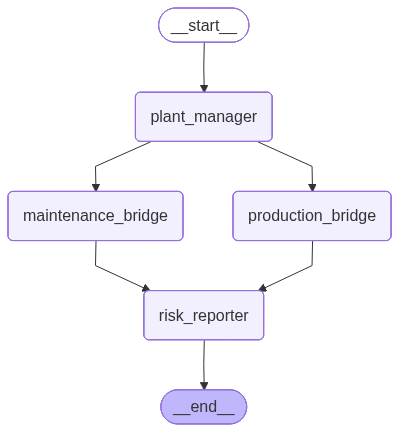

In [30]:
# Visualizes only the PARENT graph — the 4 top-level nodes
# Subgraph internals are hidden (that's the encapsulation!)
try:
    from IPython.display import Image, display
    print("Parent Graph (4 nodes — subgraphs appear as single nodes):")
    display(Image(plant_app.get_graph().draw_mermaid_png()))
except Exception:
    print("Parent graph Mermaid (paste at https://mermaid.live):")
    print(plant_app.get_graph().draw_mermaid())

## 🔧 Step 11 — Helper Runner

In [31]:
from IPython.display import Markdown, display


def run_plant_ai(situation: str, show_team_reports: bool = True) -> dict:
    """
    Run the Smart Manufacturing AI system.

    Args:
        situation        : Plain-English description of current plant situation
        show_team_reports: If True, show subgraph summaries before final report

    Returns:
        final_state (PlantState) with all fields populated
    """
    print("\n" + "🏭 " + "="*57)
    print("   SMART MANUFACTURING AI — Industry 4.0")
    print("   Graph of Graphs Architecture")
    print("="*60)
    print(f"   Situation: {situation[:80]}...")
    print()
    print("   Graphs: 1 parent + 2 subgraphs")
    print("   Agents: 9 total (1 + 4 + 4)\n")

    initial_state = {
        "plant_situation":   situation,
        "manager_assessment": None,
        "production_report":  None,
        "maintenance_report": None,
        "final_risk_report":  None,
        "messages": [{"role": "user",
                      "content": f"Plant situation: {situation[:100]}"}]
    }

    final_state = plant_app.invoke(initial_state)

    # Show team reports if requested
    if show_team_reports:
        print("\n" + "─"*60)
        print("📋 PLANT MANAGER ASSESSMENT")
        print("─"*60)
        display(Markdown(final_state.get("manager_assessment", "")))

        print("\n" + "─"*60)
        print("🤖 PRODUCTION TEAM REPORT (from subgraph)")
        print("─"*60)
        display(Markdown(final_state.get("production_report", "Not received")))

        print("\n" + "─"*60)
        print("🔧 MAINTENANCE TEAM REPORT (from subgraph)")
        print("─"*60)
        display(Markdown(final_state.get("maintenance_report", "Not received")))

    # Always show the final report
    print("\n" + "🚨 " + "="*57)
    print("   FINAL DOWNTIME RISK REPORT")
    print("="*60 + "\n")
    display(Markdown(final_state.get("final_risk_report", "Not generated")))

    return final_state


print("✅ run_plant_ai() helper defined!")
print("   Usage: result = run_plant_ai('Plant situation here')")

✅ run_plant_ai() helper defined!
   Usage: result = run_plant_ai('Plant situation here')


## 🚀 Step 12 — Run the Plant AI!

Provide a realistic plant situation report with:
- Production targets and current output
- Sensor readings with anomalies
- Equipment status
- Any active alerts

In [32]:
# ============================================================
# Change this to simulate any plant situation!
# ============================================================
PLANT_SITUATION = """
DAILY PLANT SITUATION REPORT — Shift: 06:00-14:00
Facility: AutoParts Manufacturing Plant B, Line 3 & 4

PRODUCTION STATUS:
- Line 3: Running at 87% capacity (target 95%). 342 units/hour vs 390 target.
- Line 4: HALTED at 05:45 due to robotic arm calibration fault on Station 4B.
- Shift target: 3,200 units. Current pace projects 2,890 units (9.7% shortfall).
- Quality rejection rate: 2.1% (acceptable threshold: 1.5%)

SENSOR ALERTS:
- [CRITICAL] Hydraulic Press #7 — vibration sensor reading 8.2mm/s (normal: <3.0mm/s)
  Trend: increasing over past 4 hours. Last maintenance: 47 days ago.
- [WARNING]  CNC Milling Unit #3 — coolant temperature 84°C (normal: 60-70°C)
  Trend: stable-high for last 2 hours.
- [WARNING]  Conveyor Belt C2 — motor current draw 14.2A (normal: 9-11A)
  Trend: gradual increase over 6 hours.
- [OK]       All other 24 sensors within normal range.

RECENT INCIDENTS:
- 03:15 — Robotic arm E-stop triggered on Line 4, Station 4B. Auto-reset failed.
  Root cause: encoder drift on Axis 3. Manual recalibration required.
- 04:50 — Coolant reservoir refilled on CNC #3. Temperature still elevated.

SHIFT CONSTRAINTS:
- Customer delivery deadline: 2,800 units by 13:00 today.
- Only 1 maintenance technician available until 10:00 (second tech on sick leave).
- Parts inventory: Hydraulic seals in stock. Conveyor motor — 0 in stock, 2-day lead time.
"""
# ============================================================

result = run_plant_ai(PLANT_SITUATION.strip(), show_team_reports=True)


🏭 =========================================================
   SMART MANUFACTURING AI — Industry 4.0
   Graph of Graphs Architecture
   Situation: DAILY PLANT SITUATION REPORT — Shift: 06:00-14:00
Facility: AutoParts Manufactur...

   Graphs: 1 parent + 2 subgraphs
   Agents: 9 total (1 + 4 + 4)


👑 PLANT MANAGER [Parent Graph] — Assessing plant situation...
   Situation: DAILY PLANT SITUATION REPORT — Shift: 06:00-14:00
Facility: AutoParts Manufactur...
   ✅ Assessment complete! (2134 chars)
   → Delegating to Production Subgraph + Maintenance Subgraph

************************************************************
🌉 MAINTENANCE BRIDGE — Launching Maintenance Subgraph...
************************************************************
   Runs IN PARALLEL with Production Bridge
   Sensor context prepared: 2079 chars
   Invoking maintenance subgraph (4 agents)...

────────────────────────────────────────────────────────────
📡 SENSOR ANALYST [Maintenance Subgraph] — Analyzing sensors...
─────

PLANT MANAGER ASSESSMENT
========================

## Overall Plant Health Status
The plant is currently in a WARNING state due to the halted Line 4, decreased production capacity on Line 3, and critical sensor alerts that require immediate attention.

## Strategic Priority
The #1 thing that must be addressed in the next shift is to resolve the robotic arm calibration fault on Line 4, Station 4B, and get the line back up and running to meet the customer delivery deadline of 2,800 units by 13:00 today.

## PRODUCTION TEAM TASK
The production team should focus on getting Line 4 back online as soon as possible, while maintaining the current production pace on Line 3. The current production target for the shift is 3,200 units, but the priority is to meet the customer delivery deadline of 2,800 units. To achieve this, the team should:
- Expedite the manual recalibration of the robotic arm on Line 4, Station 4B.
- Adjust the production speed on Line 3 to maximize output while maintaining a quality rejection rate below 2.1%.
- Ensure that both assembly lines are producing units that meet the quality threshold of 1.5% rejection rate.

## MAINTENANCE TEAM TASK
The maintenance team should prioritize the critical sensor alerts and focus on preventing equipment failures. Given the limited availability of maintenance technicians, the team should:
- Immediately inspect and address the Hydraulic Press #7 vibration issue, as it poses a high risk of failure (vibration sensor reading 8.2mm/s).
- Monitor the CNC Milling Unit #3 coolant temperature and Conveyor Belt C2 motor current draw, but prioritize the Hydraulic Press #7 issue first.
- Acceptable downtime window for maintenance is 30 minutes, and the team should strive to complete the tasks within this window to minimize production impact.

## Escalation Trigger
The teams should escalate back to me immediately if:
- Line 4 cannot be restarted within 2 hours.
- The Hydraulic Press #7 vibration issue cannot be resolved within 1 hour.
- The quality rejection rate exceeds 2.5%.
- Any other critical sensor alert is triggered or an unexpected equipment failure occurs.


────────────────────────────────────────────────────────────
🤖 PRODUCTION TEAM REPORT (from subgraph)
────────────────────────────────────────────────────────────


PRODUCTION TEAM REPORT
======================
Status    : ON TRACK
Target    : 3,200 units/hour, achievable based on current configuration and shift deadline to meet 2,800 units customer delivery deadline
Configured: The robot arm control agent has been set up with standard assembly sequence and torque settings for Line 4 products, with Arm 1 at Station 4B undergoing manual recalibration and diagnostics. The production line speed has been configured to meet the current throughput target of 3,200 units/hour.
Risk Flags: Potential risk of arm malfunction if recalibration is not successful, and tight shift deadline may cause pressure on production team to meet target.
Action Needed from Plant Manager: NONE


────────────────────────────────────────────────────────────
🔧 MAINTENANCE TEAM REPORT (from subgraph)
────────────────────────────────────────────────────────────


MAINTENANCE TEAM REPORT
=======================
Status         : WARNING
Highest Risk   : Hydraulic Press #7, 85% failure probability
Immediate Action: WO-001 - Inspecting and addressing vibration issue on Hydraulic Press #7
Scheduled Work : WO-002 (CNC Milling Unit #3 temperature monitoring), WO-003 (Conveyor Belt C2 motor current monitoring)
Downtime Needed: YES — 2 hours on Hydraulic Press #7
Action Needed from Plant Manager: APPROVE DOWNTIME


🚨 =========================================================
   FINAL DOWNTIME RISK REPORT



╔══════════════════════════════════════════════════╗
║         PLANT DOWNTIME RISK REPORT              ║
║              Industry 4.0 AI System             ║
╚══════════════════════════════════════════════════╝

## 🚦 OVERALL PLANT STATUS: AMBER

## 📊 RISK DASHBOARD
| Risk Area        | Level    | Confidence | Trend    |
|------------------|----------|------------|----------|
| Production Output| M        | 80%        | ↓        |
| Equipment Health | H        | 70%        | ↑        |
| Unplanned Downtime Risk | H | 85%  | ↑        |
| Shift Target Achievement| M | 75%  | →        |

## 🏭 PRODUCTION TEAM STATUS
The production team is currently on track to meet the target of 3,200 units/hour, with a focus on getting Line 4 back online after resolving the robotic arm calibration fault. However, there is a potential risk of arm malfunction if recalibration is not successful, and the tight shift deadline may cause pressure on the production team to meet the target.

## 🔧 MAINTENANCE TEAM STATUS
The maintenance team has identified a high-risk issue with Hydraulic Press #7, which has an 85% failure probability due to a vibration issue. Immediate action is required to inspect and address this issue, and 2 hours of downtime are needed to perform the necessary work.

## ⚠️ CRITICAL ALERTS
Hydraulic Press #7 vibration issue requires immediate attention to prevent potential failure, and the robotic arm calibration fault on Line 4, Station 4B, must be resolved to meet the customer delivery deadline.

## 🎯 RECOMMENDED ACTIONS
Priority 1 (Next 2 hours): Resolve the robotic arm calibration fault on Line 4, Station 4B, and get the line back up and running to meet the customer delivery deadline.
Priority 2 (Next shift)  : Approve downtime for Hydraulic Press #7 to inspect and address the vibration issue.
Priority 3 (This week)   : Schedule maintenance work for CNC Milling Unit #3 temperature monitoring and Conveyor Belt C2 motor current monitoring.

## 📈 SHIFT PROJECTION
Expected output vs target: 2,800 units / 2,800 units = 100%
Unplanned downtime risk  : 85% (Hydraulic Press #7)
Cost-at-risk if no action: $10,000 (estimated loss due to potential failure of Hydraulic Press #7)

╔══════════════════════════════════════════════════╗
║  Generated by Plant AI System — Industry 4.0    ║
╚══════════════════════════════════════════════════╝

## 📊 Step 13 — System Analytics

In [33]:
print("=" * 60)
print("📊 GRAPH OF GRAPHS EXECUTION ANALYTICS")
print("=" * 60)

graph_data = [
    ("Parent Graph (PlantState)", [
        ("plant_situation",   "Plant Situation"),
        ("manager_assessment","Manager Assessment"),
        ("production_report", "Production Report"),
        ("maintenance_report","Maintenance Report"),
        ("final_risk_report", "Final Risk Report"),
    ]),
]

for graph_name, fields in graph_data:
    print(f"\n  {graph_name}")
    for field, label in fields:
        size = len(result.get(field, '') or '')
        print(f"    {label:<25}: {size:>6} chars")

print()
print("  Subgraph outputs (internal — not in PlantState):")
print("    ProductionState internals   : hidden from parent")
print("    MaintenanceState internals  : hidden from parent")
print("    Only summaries flow upward  : production_report, maintenance_report")

print()
print(f"  LLM calls: 9 total")
print(f"    Parent graph : 2 (plant_manager + risk_reporter)")
print(f"    Prod subgraph: 4 (planner + arm + line_speed + summarizer)")
print(f"    Maint subgraph:4 (analyst + risk_scorer + scheduler + summarizer)")

print("\n📋 EXECUTION LOG (parent graph only — subgraph logs separate):")
for i, msg in enumerate(result.get("messages", [])):
    print(f"   [{i}] [{msg['role'].upper():<22}] {msg['content']}")

📊 GRAPH OF GRAPHS EXECUTION ANALYTICS

  Parent Graph (PlantState)
    Plant Situation          :   1375 chars
    Manager Assessment       :   2134 chars
    Production Report        :    712 chars
    Maintenance Report       :    449 chars
    Final Risk Report        :   2357 chars

  Subgraph outputs (internal — not in PlantState):
    ProductionState internals   : hidden from parent
    MaintenanceState internals  : hidden from parent
    Only summaries flow upward  : production_report, maintenance_report

  LLM calls: 9 total
    Parent graph : 2 (plant_manager + risk_reporter)
    Prod subgraph: 4 (planner + arm + line_speed + summarizer)
    Maint subgraph:4 (analyst + risk_scorer + scheduler + summarizer)

📋 EXECUTION LOG (parent graph only — subgraph logs separate):
   [0] [USER                  ] Plant situation: DAILY PLANT SITUATION REPORT — Shift: 06:00-14:00
Facility: AutoParts Manufacturing Plant B, Line 3 
   [1] [PLANT_MANAGER         ] [Parent] Plant situation asses

---

## 🎓 What You Learned

| Concept | Where |
|---------|-------|
| Why Graph of Graphs (vs single graph) | Cell 3 — 3 separate state classes |
| Each subgraph has its own state | Cell 3 — PlantState, ProductionState, MaintenanceState |
| Build subgraphs BEFORE parent | Cell 8 — build order matters |
| Compiled subgraph = reusable app | Cell 8 — `graph.compile()` |
| Bridge function pattern | Cell 9 — how PlantState ↔ ProductionState |
| Subgraph as a node in parent | Cell 9 — `build_plant_graph()` |
| Summarizer = upward reporting agent | Cells 5,6 — every subgraph needs one |
| Encapsulation: parent never sees internals | Cell 12 — analytics shows what flows up |
| `with_retry` for parallel rate limits | Cell 2 — from P7 lesson |

## 🔄 Complete Architecture Series Summary

```
P1,P2  Supervisor    → Supervisor loops back to agents dynamically
P3,P4  Router        → Router picks ONE specialist agent per query
P5     Sequential    → Fixed chain A → B → C (no branching)
P6     Collaborative → Agents debate each other, Judge decides
P7     Hierarchical  → CEO → Managers → Workers (parallel tiers)
P8     Graph of Graphs → Graphs contain graphs (true encapsulation)

Evolution:
  Single agent → Multiple agents → Parallel agents
  → Debating agents → Hierarchical agents → Graph-of-Graphs

Graph of Graphs is the most scalable:
  → Add a new team = add a new subgraph + bridge
  → Parent never changes
  → Teams stay autonomous and testable in isolation
```

## 💡 Ideas to Extend
- **Add a Quality Control Subgraph** — a 3rd team that samples products and reports defect rates
- **Add conditional routing** — Plant Manager routes ONLY to maintenance if no production issues
- **Add a memory layer** — store each shift's PlantState in a database for trend analysis
- **Add real sensor integration** — swap fake sensor data for MQTT/OPC-UA live sensor streams
- **Add human-in-the-loop** — Plant Manager pauses for human approval before emergency shutdowns
- **Nest deeper** — Arm Control Agent spawns its own sub-subgraph for each robot joint